# Boundaries from spectra

**What this shows:** the three rompy-swan classes that build SWAN boundaries from
wave spectra of a larger model, their options, and how to check the result.

**Prerequisites:** [Tutorial 4: Wave boundaries](../tutorial/04_wave_boundaries.ipynb).

**You will learn:**

- how `Boundnest1` selects spectra along every open boundary, and how `sel_method`,
  `tolerance` and `spacing` change the selection
- how `BoundspecSide` and `BoundspecSegmentXY` write boundaries on one side or on
  segments, as TPAR parameters or full spectra
- what happens when the source does not cover the boundary
- which SWAN commands read other models' boundary files directly

**Data used:** `ww3-spectra-20230101-short.nc` (3-hourly WAVEWATCH III spectra at 19
sites off Perth) and `etopo15s_perth.nc` (for the maps).

## Setup

In [1]:
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import wavespectra
import xarray as xr
from rompy.core.source import SourceWavespectra
from rompy.core.time import TimeRange
from rompy.logging import config as logging_config

from rompy_swan.grid import SwanGrid

logging_config.update(level="WARNING")

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "boundaries_from_spectra"
shutil.rmtree(OUT_DIR, ignore_errors=True)
OUT_DIR.mkdir(parents=True)

grid = SwanGrid(x0=114.5, y0=-32.8, dx=0.02, dy=0.02, nx=71, ny=66)
period = TimeRange(start="2023-01-01T12:00", end="2023-01-01T18:00", interval="1h")
source = SourceWavespectra(uri=DATA_DIR / "ww3-spectra-20230101-short.nc", reader="read_ww3")
sites = source.open().sel(time="2023-01-01T15:00")
etopo = xr.open_dataset(DATA_DIR / "etopo15s_perth.nc")


def plot_boundary(ax, lon, lat, hs, title):
    """Map the source sites and the boundary points, coloured by Hs."""
    kwargs = {"cmap": "viridis", "vmin": 3.4, "vmax": 4.1, "edgecolors": "k"}
    etopo.z.plot.contour(ax=ax, levels=[0], colors="k", linewidths=0.6)
    x0, y0, x1, y1 = grid.bbox()
    ax.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], "r", linewidth=0.8, zorder=0)
    ax.scatter(sites.lon, sites.lat, c=sites.spec.hs(), s=200, marker="s", **kwargs)
    points = ax.scatter(lon, lat, c=hs, s=40, **kwargs)
    ax.set(xlim=(113.8, 116), ylim=(-34.2, -30.8), title=title, xlabel="", ylabel="")
    ax.set_aspect("equal")
    return points

## 1. `Boundnest1`: every open boundary

`Boundnest1` selects spectra at points around the grid and writes them to one SWAN
spectral file, read with `BOUNDNEST1`. The selection options come from rompy:

- `sel_method="idw"` interpolates between the sites within `tolerance`, weighting by
  inverse distance; `"nearest"` takes the closest site within `tolerance`;
- `spacing` sets the distance between boundary points; `"parent"` uses the spacing of
  the source sites; by default every grid point on the boundary is used;
- `rectangle` is `"closed"` (all four sides) or `"open"`.

BOUNDNEST1 NEST 'idw.bnd' CLOSED


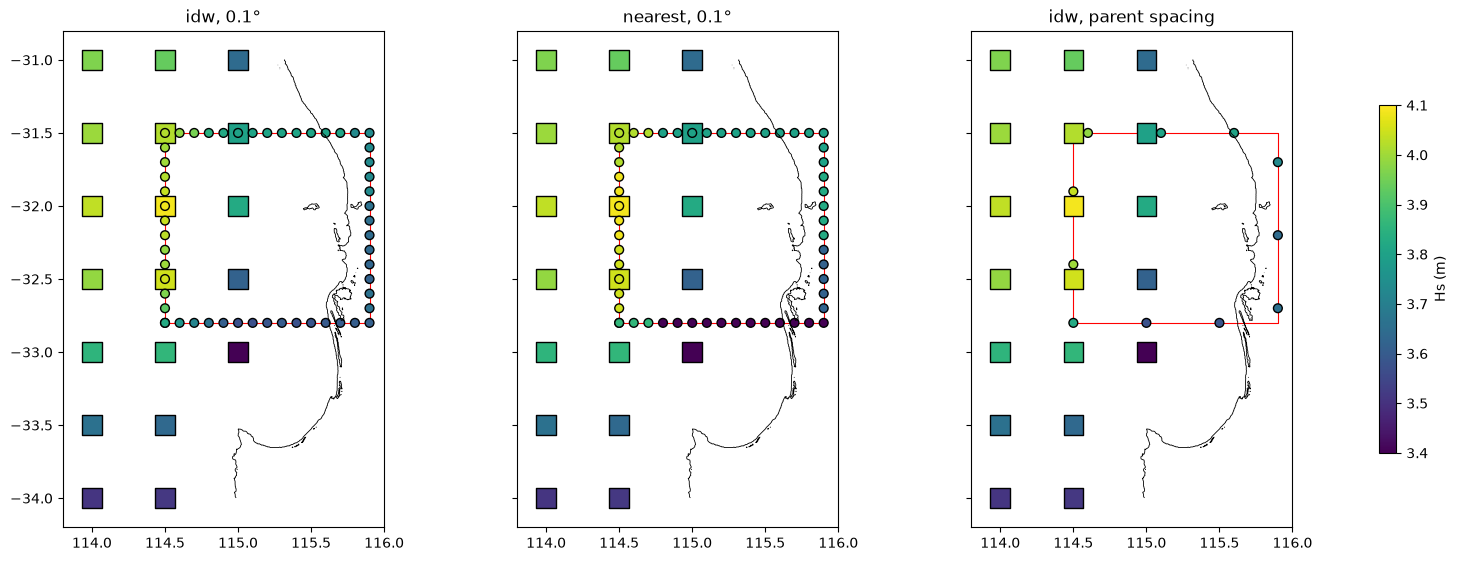

In [2]:
from rompy_swan.boundary import Boundnest1

options = {
    "idw, 0.1°": {"sel_method": "idw", "sel_method_kwargs": {"tolerance": 1.5}, "spacing": 0.1},
    "nearest, 0.1°": {"sel_method": "nearest", "sel_method_kwargs": {"tolerance": 1.0}, "spacing": 0.1},
    "idw, parent spacing": {"sel_method": "idw", "sel_method_kwargs": {"tolerance": 1.5}, "spacing": "parent"},
}
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), sharey=True, layout="constrained")
for ax, (name, kwargs) in zip(axes, options.items()):
    nest = Boundnest1(id=name.split(",")[0], source=source, **kwargs)
    bnd_file, cmd = nest.get(OUT_DIR, grid=grid, time=period)
    spectra = wavespectra.read_swan(bnd_file).sel(time="2023-01-01T15:00")
    points = plot_boundary(ax, spectra.lon, spectra.lat, spectra.spec.hs(), name)
fig.colorbar(points, ax=axes, label="Hs (m)", shrink=0.7)
print(cmd)

`idw` gives smooth changes along the boundary; `nearest` copies each site, so the
values change in steps. With the parent spacing there are only a few boundary points,
and SWAN interpolates between them.

## 2. When the source does not cover the boundary

With a small tolerance, points far from every site get no spectrum. rompy-swan stops
with an error instead of writing incomplete boundary files:

In [3]:
try:
    Boundnest1(
        id="short", source=source, sel_method="idw", sel_method_kwargs={"tolerance": 0.3}, spacing=0.1
    ).get(OUT_DIR, grid=grid, time=period)
except ValueError as err:
    print(err)

Missing spectra at 49 boundary point(s) for short.bnd. The boundary points are probably outside the spectra dataset or beyond the selection tolerance: check `sel_method_kwargs` and the extent of the source, or use sel_method='nearest'.


Increase the tolerance, use `nearest`, or use a source that covers the whole
boundary. Points on land, like the eastern side here, are ignored by SWAN, but still
need a spectrum in the file.

## 3. `BoundspecSide`: one side

`BoundspecSide` averages the spectra along one side and writes a `BOUNDSPEC` command
with a file. `file_type="tpar"` (default) writes the integrated parameters (Hs, peak
period, direction, spreading) as a TPAR file; `"spec2d"` writes the full spectrum.

In [4]:
from rompy_swan.boundary import BoundspecSide
from rompy_swan.subcomponents.boundary import SIDE

for file_type in ["tpar", "spec2d"]:
    side = BoundspecSide(
        id="west",
        source=source,
        location=SIDE(side="west"),
        file_type=file_type,
        sel_method="idw",
        sel_method_kwargs={"tolerance": 0.6},
    )
    filename, cmd = side.get(OUT_DIR, grid=grid, time=period)
    print(cmd, "\n")
print(filename.with_name("west_tpar_west_000.bnd").read_text())

BOUND SHAPESPEC JONSWAP gamma=3.3 PEAK DSPR DEGREES
BOUNDSPEC SIDE WEST CCW CONSTANT FILE fname='west_tpar_west_000.bnd' seq=1 



BOUND SHAPESPEC JONSWAP gamma=3.3 PEAK DSPR DEGREES
BOUNDSPEC SIDE WEST CCW CONSTANT FILE fname='west_spec2d_west_000.bnd' seq=1 

TPAR
20230101.120000 3.91 14.17 218.58 23.89
20230101.150000 4.03 14.13 219.34 28.01
20230101.180000 3.98 14.13 220.06 32.63



TPAR boundaries use the spectral shape of `shapespec` (JONSWAP by default) with the
parameters from the data. Use `spec2d` when the shape matters, e.g. with swell and
wind sea from different directions.

## 4. `BoundspecSegmentXY`: segments

`BoundspecSegmentXY` splits the boundary into segments between consecutive points and
writes one averaged boundary per segment. The points come from sides (`SIDE`, or
several contiguous sides with `SIDES`) or from coordinates (`XY`). Here the south,
west and north sides, clockwise, every 0.325°:

In [5]:
from rompy_swan.boundary import BoundspecSegmentXY
from rompy_swan.subcomponents.boundary import SIDES

segments = BoundspecSegmentXY(
    id="swn",
    source=source,
    location=SIDES(
        sides=[
            SIDE(side="south", direction="clockwise"),
            SIDE(side="west", direction="clockwise"),
            SIDE(side="north", direction="clockwise"),
        ]
    ),
    sel_method="idw",
    sel_method_kwargs={"tolerance": 1.5},
    spacing=0.325,
)
filenames, cmd = segments.get(OUT_DIR, grid=grid, time=period)
print(cmd)

BOUND SHAPESPEC JONSWAP gamma=3.3 PEAK DSPR DEGREES
BOUNDSPEC SEGMENT XY 115.90000000 -32.80000000 115.57500000 -32.80000000 CONSTANT FILE fname='swn_tpar_000.bnd' seq=1
BOUNDSPEC SEGMENT XY 115.57500000 -32.80000000 115.25000000 -32.80000000 CONSTANT FILE fname='swn_tpar_001.bnd' seq=1
BOUNDSPEC SEGMENT XY 115.25000000 -32.80000000 114.92500000 -32.80000000 CONSTANT FILE fname='swn_tpar_002.bnd' seq=1
BOUNDSPEC SEGMENT XY 114.92500000 -32.80000000 114.60000000 -32.80000000 CONSTANT FILE fname='swn_tpar_003.bnd' seq=1
BOUNDSPEC SEGMENT XY 114.60000000 -32.80000000 114.50000000 -32.80000000 CONSTANT FILE fname='swn_tpar_004.bnd' seq=1
BOUNDSPEC SEGMENT XY 114.50000000 -32.80000000 114.50000000 -32.47500000 CONSTANT FILE fname='swn_tpar_005.bnd' seq=1
BOUNDSPEC SEGMENT XY 114.50000000 -32.47500000 114.50000000 -32.15000000 CONSTANT FILE fname='swn_tpar_006.bnd' seq=1
BOUNDSPEC SEGMENT XY 114.50000000 -32.15000000 114.50000000 -31.82500000 CONSTANT FILE fname='swn_tpar_007.bnd' seq=1
BOUN

The sides must follow each other in the direction given. This leaves the eastern
(land) side without a boundary, which `Boundnest1` cannot do.

## 5. Boundary files from other models

SWAN also reads boundary files written by other models directly:

- `BOUNDNEST1`: spectra written by a parent SWAN run (`NESTOUT`), see
  [Nesting](nesting.ipynb);
- `BOUNDNEST2`: WAM output;
- `BOUNDNEST3`: WAVEWATCH III boundary files written by `ww3_outp`.

In [6]:
from rompy_swan.components.boundary import BOUNDNEST3

print(BOUNDNEST3(fname="ww3_boundary.out", format="unformatted").render())

BOUNDNEST3 WW3 fname='ww3_boundary.out' UNFORMATTED CLOSED


These commands only point to the files; you provide them in the workspace.

## Summary

- `Boundnest1` writes spectra along every open side; choose `idw` or `nearest`, the
  `tolerance` and the `spacing`, and check the result against the source.
- `BoundspecSide` (one side) and `BoundspecSegmentXY` (segments) write TPAR
  parameters or full spectra.
- Missing spectra stop the generation with an error.
- `BOUNDNEST1/2/3` read files from SWAN, WAM or WAVEWATCH III runs directly.